# Decision Tree Using Scikit-learn library

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt 
from sklearn import tree

In [59]:
import seaborn as sns

In [61]:
from scipy.stats import chi2_contingency

## Load Data

In [3]:
data = pd.read_csv("Employee.csv")
data

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1
...,...,...,...,...,...,...,...,...,...
4648,Bachelors,2013,Bangalore,3,26,Female,No,4,0
4649,Masters,2013,Pune,2,37,Male,No,2,1
4650,Masters,2018,New Delhi,3,27,Male,No,5,1
4651,Bachelors,2012,Bangalore,3,30,Male,Yes,2,0


## Basic EDA

### What is the distribution of education qualifications among employees?

In [4]:
education_uniques, education_count = np.unique(data["Education"], return_counts=True)
education_uniques

array(['Bachelors', 'Masters', 'PHD'], dtype=object)

In [5]:
education_count

array([3601,  873,  179], dtype=int64)

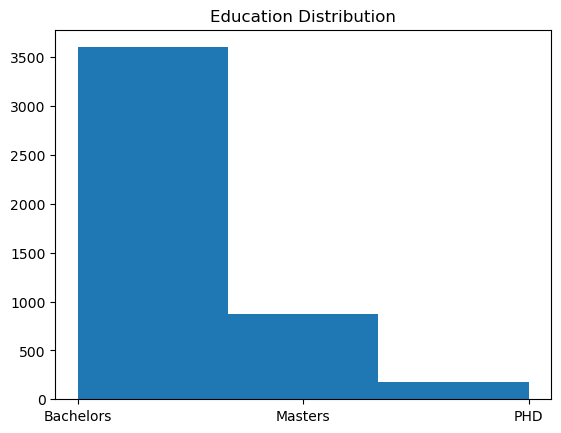

In [6]:
# plot
plt.hist(data["Education"], bins=3)
plt.title("Education Distribution")
plt.show()

There are 3601 employees with Bachelors degree,
873 employees with Master degree,
and 179 employees with PHD

### How does the length of service (Joining Year) vary across different cities?

In [10]:
bangalore_data = data[data["City"] == "Bangalore"]
bangalore_data

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
5,Bachelors,2016,Bangalore,3,22,Male,No,0,0
7,Bachelors,2016,Bangalore,3,34,Female,No,2,1
10,Masters,2012,Bangalore,3,27,Male,No,5,1
...,...,...,...,...,...,...,...,...,...
4643,Bachelors,2013,Bangalore,3,31,Female,No,5,0
4646,Bachelors,2013,Bangalore,3,25,Female,No,3,0
4648,Bachelors,2013,Bangalore,3,26,Female,No,4,0
4651,Bachelors,2012,Bangalore,3,30,Male,Yes,2,0


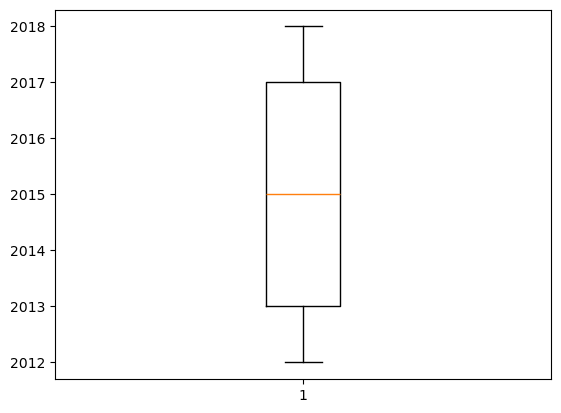

In [12]:
plt.boxplot(bangalore_data["JoiningYear"])
plt.show()

In [24]:
# function to add joining year data of a city to a dict to be used for boxplot
joining_year_dict = {}
def add_joining_year(city_name):
    # check if city exists
    if city_name not in data["City"].values:
        print(f"{city_name} does not exist in this dataset.")
        return
    
    # add joining year for this city
    city_joining_year = data[data["City"] == city_name]["JoiningYear"]
    joining_year_dict[city_name] = city_joining_year

In [26]:
# add joining year of every cities to joining_year_dict
for city_name in data["City"].unique():
    add_joining_year(city_name)

joining_year_dict

{'Bangalore': 0       2017
 3       2016
 5       2016
 7       2016
 10      2012
         ... 
 4643    2013
 4646    2013
 4648    2013
 4651    2012
 4652    2015
 Name: JoiningYear, Length: 2228, dtype: int64,
 'Pune': 1       2013
 4       2017
 8       2016
 11      2016
 12      2018
         ... 
 4630    2012
 4644    2015
 4645    2017
 4647    2016
 4649    2013
 Name: JoiningYear, Length: 1268, dtype: int64,
 'New Delhi': 2       2014
 6       2015
 9       2017
 19      2016
 21      2017
         ... 
 4616    2015
 4618    2017
 4634    2016
 4636    2014
 4650    2018
 Name: JoiningYear, Length: 1157, dtype: int64}

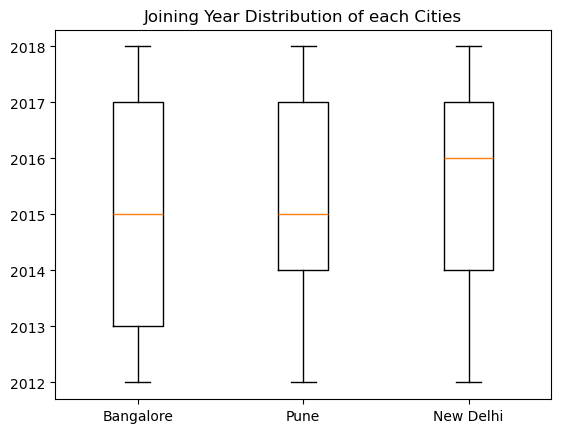

In [30]:
# boxplot joining year of every cities
plt.boxplot(joining_year_dict.values(), labels=joining_year_dict.keys())
plt.title("Joining Year Distribution of each Cities")
plt.show()

50% of employees from Bangalore join from the year 2012-2015.

50% of employees from Pune join from the year 2012-2015.

50% of employees from New Delhi join from the year 2012-2016.

### Is there a correlation between Payment Tier and Experience in Current Domain?

In [ ]:
data[["PaymentTier", "ExperienceInCurrentDomain"]]

,PaymentTier,ExperienceInCurrentDomain
0,3,0
1,1,3
2,3,2
3,3,5
4,3,2
...,...,...
4648,3,4
4649,2,2
4650,3,5
4651,3,2


In [54]:
table_count = pd.crosstab(data["ExperienceInCurrentDomain"], data["PaymentTier"])
table_count

PaymentTier,1,2,3
ExperienceInCurrentDomain,,,
0,25,66,264
1,36,90,432
2,51,252,784
3,41,150,595
4,43,184,704
5,45,174,700
6,1,1,6
7,1,1,7


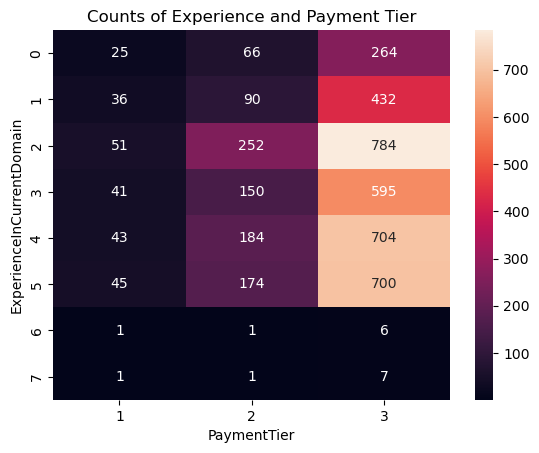

In [55]:
sns.heatmap(table_count, annot=True, fmt='d')
plt.title("Counts of Experience and Payment Tier")
plt.show()

In [56]:
table_prob = pd.crosstab(data["ExperienceInCurrentDomain"], data["PaymentTier"], normalize="index")
table_prob

PaymentTier,1,2,3
ExperienceInCurrentDomain,,,
0,0.070423,0.185915,0.743662
1,0.064516,0.161290,0.774194
2,0.046918,0.231831,0.721251
3,0.052163,0.190840,0.756997
4,0.046187,0.197637,0.756176
5,0.048966,0.189336,0.761697
6,0.125000,0.125000,0.750000
7,0.111111,0.111111,0.777778


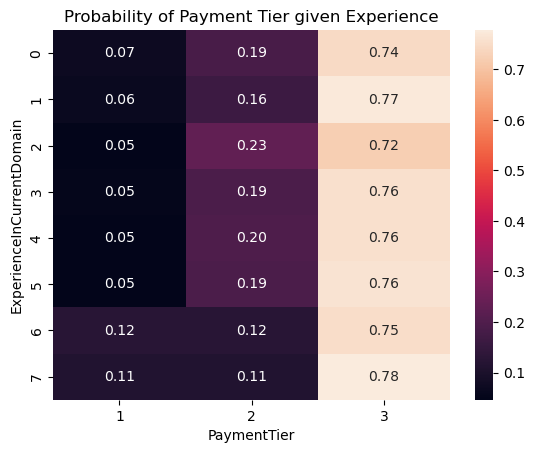

In [58]:
sns.heatmap(table_prob, annot=True, fmt='.2f')
plt.title("Probability of Payment Tier given Experience")
plt.show()

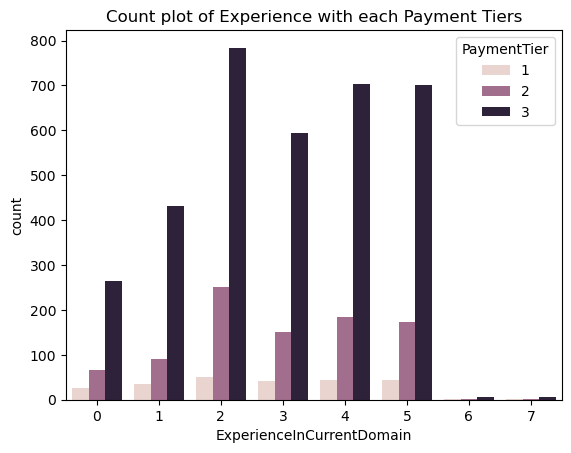

In [60]:
sns.countplot(data, x="ExperienceInCurrentDomain", hue="PaymentTier")
plt.title("Count plot of Experience with each Payment Tiers")
plt.show()

In [62]:
table_count.values

array([[ 25,  66, 264],
       [ 36,  90, 432],
       [ 51, 252, 784],
       [ 41, 150, 595],
       [ 43, 184, 704],
       [ 45, 174, 700],
       [  1,   1,   6],
       [  1,   1,   7]], dtype=int64)

In [63]:
stats, p_value, dof, expected_freq = chi2_contingency(table_count.values)
p_value

0.1268478746880473

p value > 0.05 which means there is no correlation between Payment Tier and Experience in Current Domain

### What is the gender distribution within the workforce?

In [65]:
gender_uniques, gender_count = np.unique(data["Gender"], return_counts=True)
print(gender_uniques)
print(gender_count)

['Female' 'Male']
[1875 2778]


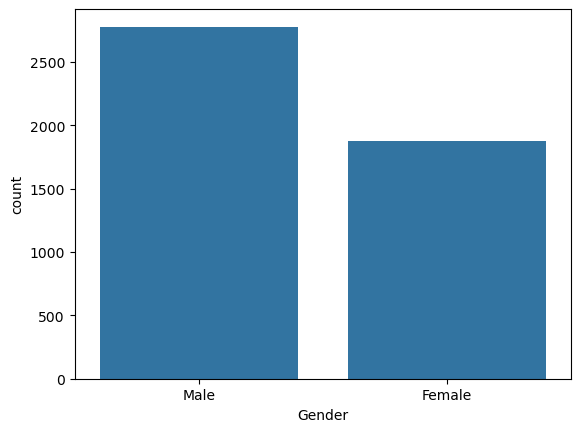

In [ ]:
sns.countplot(data, x="Gender")
plt.title("Gender Distribution")
plt.show()

There are more males than females. 1875 females and 2778 males

### Are there any patterns in leave-taking behavior among employees?

Cateorigcal Columns

In [69]:
leave_data = data[data["LeaveOrNot"] == 1]
leave_data

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
1,Bachelors,2013,Pune,1,28,Female,No,3,1
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1
7,Bachelors,2016,Bangalore,3,34,Female,No,2,1
10,Masters,2012,Bangalore,3,27,Male,No,5,1
...,...,...,...,...,...,...,...,...,...
4639,Bachelors,2017,Bangalore,3,28,Male,No,0,1
4641,Bachelors,2016,Bangalore,1,33,Female,No,0,1
4644,Bachelors,2015,Pune,3,32,Female,Yes,1,1
4649,Masters,2013,Pune,2,37,Male,No,2,1


In [73]:
data["Education"].value_counts()

Education
Bachelors    3601
Masters       873
PHD           179
Name: count, dtype: int64

In [74]:
leave_data["Education"].value_counts()

Education
Bachelors    1129
Masters       426
PHD            45
Name: count, dtype: int64

In [76]:
column_count_uniques = pd.merge(data["Education"].value_counts(), leave_data["Education"].value_counts(), on="Education")
column_count_uniques

,count_x,count_y
Education,,
Bachelors,3601,1129
Masters,873,426
PHD,179,45


In [77]:
column_count_uniques["p"] = column_count_uniques["count_y"] / column_count_uniques["count_x"]
column_count_uniques

,count_x,count_y,p
Education,,,
Bachelors,3601,1129,0.313524
Masters,873,426,0.487973
PHD,179,45,0.251397


In [80]:
column_count_uniques.index

Index(['Bachelors', 'Masters', 'PHD'], dtype='object', name='Education')

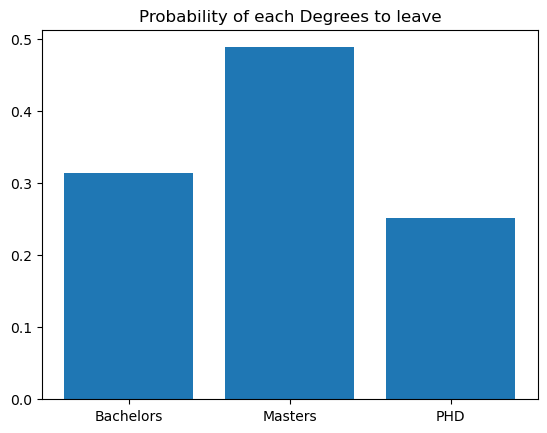

In [ ]:
plt.bar(column_count_uniques.index, column_count_uniques["p"])
plt.title("Probability of each Degrees to leave")
plt.show()

In [87]:
# probability to leave for cateorigcal columns
def get_probability_to_leave(column_name):
    # check if column exists
    if column_name not in data.columns or column_name not in leave_data.columns:
        print(f"Column {column_name} does not exist on the dataset.")
        return
    # count uniques for all data and leave data of this column
    column_count_uniques = pd.merge(data[column_name].value_counts(), leave_data[column_name].value_counts(), on=column_name)
    # calculate probability to leave given each unique values
    column_count_uniques["p"] = column_count_uniques["count_y"] / column_count_uniques["count_x"]
    return column_count_uniques

get_probability_to_leave("City")

,count_x,count_y,p
City,,,
Bangalore,2228,595,0.267056
Pune,1268,639,0.503943
New Delhi,1157,366,0.316335


In [88]:
# get probability to leave for every cateorigcal columns
education_leave_prob = get_probability_to_leave("Education")
city_leave_prob = get_probability_to_leave("City")
payment_leave_prob = get_probability_to_leave("PaymentTier")
gender_leave_prob = get_probability_to_leave("Gender")
benched_leave_prob = get_probability_to_leave("EverBenched")

In [109]:
payment_leave_prob.index = payment_leave_prob.index.astype(str)
payment_leave_prob.index

Index(['3', '2', '1'], dtype='object', name='PaymentTier')

In [111]:
payment_leave_prob

,count_x,count_y,p
PaymentTier,,,
3,3492,961,0.275200
2,918,550,0.599129
1,243,89,0.366255


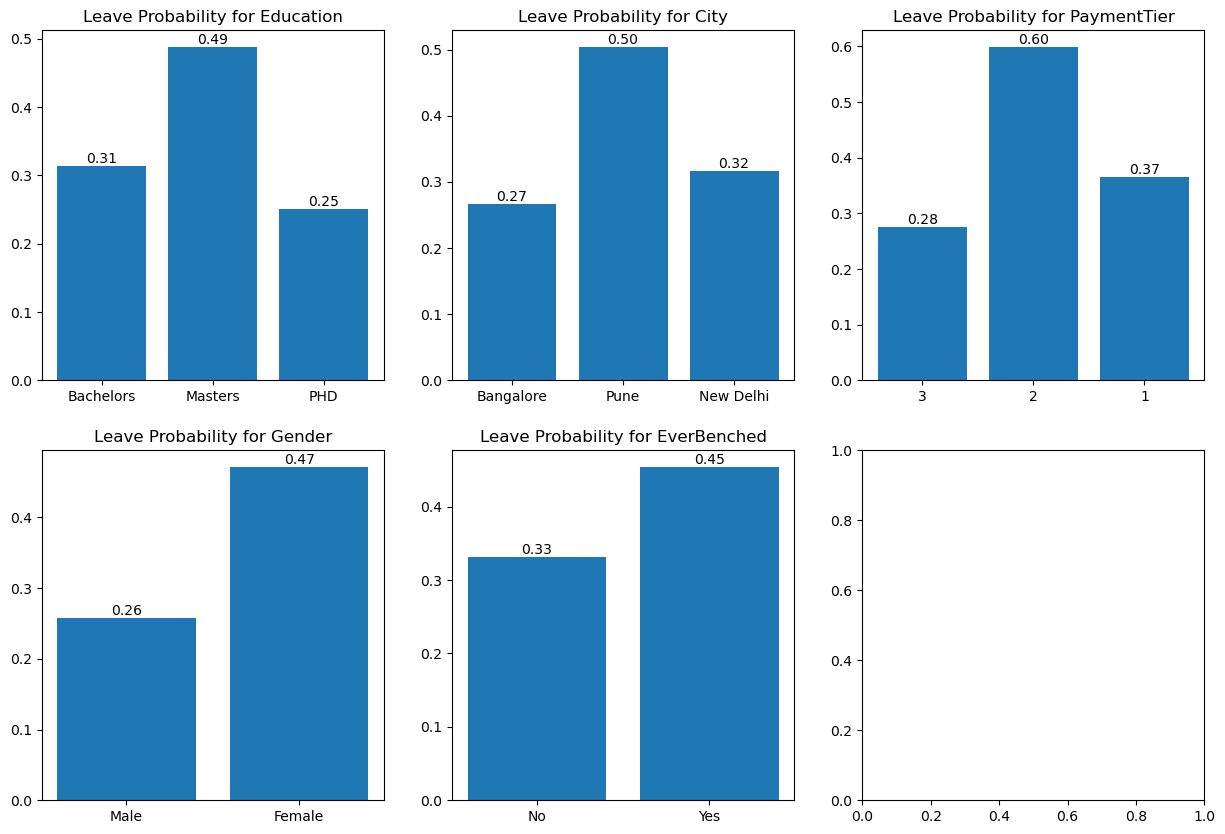

In [110]:
# bar plot of probability to leave for every cateorigcal columns
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
def plot_prob(x_index, y_index, prob_data):
    axs[x_index, y_index].set_title(f"Leave Probability for {prob_data.index.name}")
    bar = axs[x_index, y_index].bar(prob_data.index, prob_data["p"])
    axs[x_index, y_index].bar_label(bar, fmt="%.2f")

plot_prob(0, 0, education_leave_prob)
plot_prob(0, 1, city_leave_prob)
plot_prob(0, 2, payment_leave_prob)
plot_prob(1, 0, gender_leave_prob)
plot_prob(1, 1, benched_leave_prob)

plt.show()

Numerical Columns

In [122]:
no_leave_data = data[data["LeaveOrNot"] == 0]
no_leave_data

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
5,Bachelors,2016,Bangalore,3,22,Male,No,0,0
6,Bachelors,2015,New Delhi,3,38,Male,No,0,0
8,Bachelors,2016,Pune,3,23,Male,No,1,0
...,...,...,...,...,...,...,...,...,...
4646,Bachelors,2013,Bangalore,3,25,Female,No,3,0
4647,Bachelors,2016,Pune,3,30,Male,No,2,0
4648,Bachelors,2013,Bangalore,3,26,Female,No,4,0
4651,Bachelors,2012,Bangalore,3,30,Male,Yes,2,0


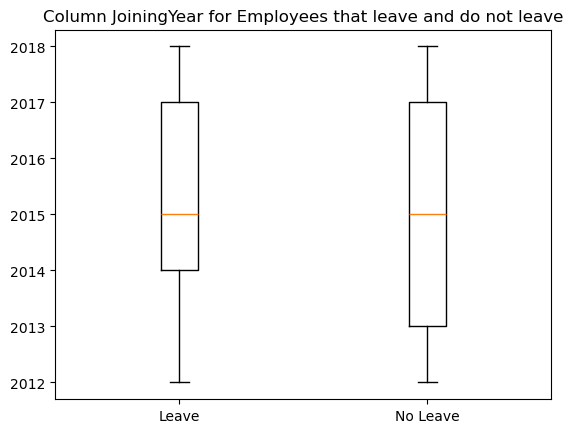

In [127]:
# box plot comparing leave and no leave data for each numerical columns
def box_compare(column_name):
     # check if column exists
    if column_name not in no_leave_data.columns or column_name not in leave_data.columns:
        print(f"Column {column_name} does not exist on the dataset.")
        return

    plt.boxplot([leave_data[column_name], no_leave_data[column_name]], labels=["Leave", "No Leave"])
    plt.title(f"Column {column_name} for Employees that leave and do not leave")
    plt.show()

box_compare("JoiningYear")

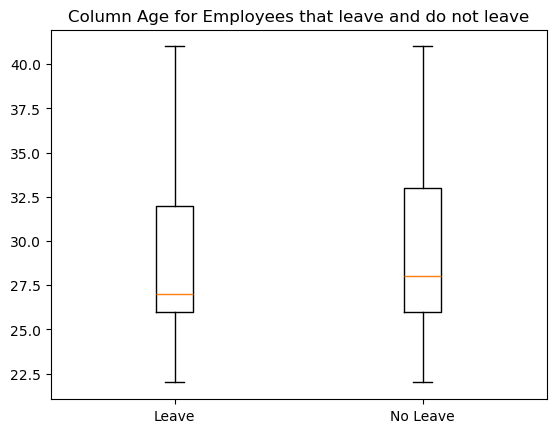

In [128]:
box_compare("Age")

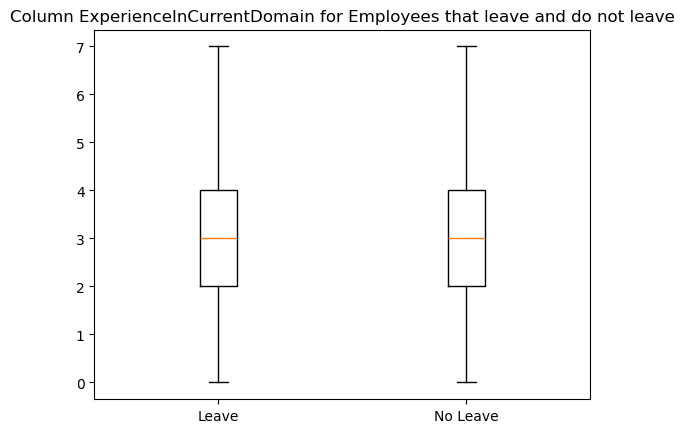

In [129]:
box_compare("ExperienceInCurrentDomain")

Correlation Test